# Analisi e validazione del dataset `User Listening History`

Questo notebook documenta l’analisi esplorativa e gli interventi di pulizia effettuati sul dataset `User Listening History.csv`, utilizzato come base per la modellazione delle collection `listeners` e `listening_history` nel progetto MongoDB.

L'obiettivo dell'analisi è:
- esplorare la struttura del dataset `listening_history`
- verificare qualità e coerenza dei dati
- individuare anomalie, nulli, duplicati e colonne da trattare
- preparare un dataset pulito e coerente da usare nelle fasi successive del progetto


## 1. Caricamento del dataset

In questa sezione viene caricato il file `User Listening History.csv` e viene effettuata una prima ispezione della struttura generale del dataset.

In [1]:
import pandas as pd
import numpy as np

DATA_PATH = "/kaggle/input/datasets/undefinenull/million-song-dataset-spotify-lastfm/User Listening History.csv" #sostuire con il proprio path locale del dataset

df_hist = pd.read_csv(DATA_PATH)
df_hist.head(20)

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
3,TRTUCUY128F92E1D24,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
4,TRHDDQG12903CB53EE,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
5,TRGRDEC128F423C07D,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
6,TRRYCBO128F932A2C7,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
7,TRUTULC128F4293712,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
8,TRAAHSY128F147BB5C,b80344d063b5ccb3212f76538f3d9e43d87dca9e,2
9,TRDLMWP128F426BF6C,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


## 2. Panoramica del dataset

Si analizzano dimensione, colonne e tipi logici dei dati, così da ottenere una visione iniziale delle informazioni disponibili e dei campi rilevanti per il progetto.

In [2]:
print(f"Dimensione dataset: {df_hist.shape}")
print(f"Colonne dataset : {df_hist.columns.tolist()}")
print("---------Info dataset------")
df_hist.info()

Dimensione dataset: (9711301, 3)
Colonne dataset : ['track_id', 'user_id', 'playcount']
---------Info dataset------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9711301 entries, 0 to 9711300
Data columns (total 3 columns):
 #   Column     Dtype 
---  ------     ----- 
 0   track_id   object
 1   user_id    object
 2   playcount  int64 
dtypes: int64(1), object(2)
memory usage: 222.3+ MB


### Osservazioni iniziali

- Il dataset contiene ~970k record
- Le colonne principali sono:
  - track_id
  - user_id
  - playcount
- I tipi di dato risultano coerenti (object per ID, int per playcount)

Il dataset sembra rappresentare una relazione utente-traccia con numero di ascolti aggregati.

## 3. Analisi esplorativa iniziale

In questa sezione vengono analizzate alcune metriche di base del dataset per comprendere:
- numero di utenti unici
- numero di tracce uniche
- distribuzione del numero di ascolti (`playcount`)

In [3]:
print("Numero utenti unici:", df_hist["user_id"].nunique())
print("Numero tracce uniche:", df_hist["track_id"].nunique())

print("\nStatistiche playcount:")
print(df_hist["playcount"].describe())

Numero utenti unici: 962037
Numero tracce uniche: 30459

Statistiche playcount:
count    9.711301e+06
mean     2.630946e+00
std      5.706324e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      2.948000e+03
Name: playcount, dtype: float64


In [4]:
top_tracks = df_hist.groupby("track_id")["playcount"].sum().sort_values(ascending=False).head(10)
print("\nTop 10 tracce per numero totale di ascolti:")
print(top_tracks)


Top 10 tracce per numero totale di ascolti:
track_id
TRONYHY128F92C9D11    527893
TRUFTBY128F93450B8    111615
TRZNAHL128F9327D5A    111596
TRCPXID128F92D5D3C     91461
TRPGPDK12903CCC651     91448
TRXWAZC128F9314B3E     87745
TROMKCG128F9320C09     87050
TRPFYYL128F92F7144     85079
TRGCHLH12903CB7352     78443
TRAALAH128E078234A     76893
Name: playcount, dtype: int64


### Osservazioni

- Il dataset contiene un numero molto elevato di utenti unici (~962k), indicando una forte eterogeneità nel comportamento di ascolto.

- Il numero di tracce uniche (~30k) è significativamente inferiore rispetto agli utenti, suggerendo che molte tracce sono condivise tra diversi utenti.

- La distribuzione di `playcount` è fortemente sbilanciata:
  - il valore mediano è 1
  - il 75% dei valori è ≤ 2
  → la maggior parte delle interazioni rappresenta pochi ascolti per coppia utente-traccia

- La presenza di un valore massimo molto elevato (2948) indica l’esistenza di outlier, ovvero utenti che ascoltano alcune tracce in modo estremamente frequente.

- Le tracce più popolari mostrano un numero totale di ascolti molto superiore rispetto alla media, evidenziando un comportamento tipico di distribuzione “long tail”, in cui poche tracce concentrano la maggior parte degli ascolti.

- Il dataset sembra rappresentare dati già aggregati per coppia (`user_id`, `track_id`), dove `playcount` indica il numero totale di ascolti per quella specifica combinazione.

## 4. Controllo qualità dei dati

In questa sezione vengono analizzati gli aspetti legati alla qualità del dataset, in particolare:

- presenza di valori nulli
- duplicati
- coerenza dei tipi di dato
- presenza di valori anomali

L’obiettivo è individuare eventuali problemi che potrebbero influenzare le analisi successive o la modellazione del database.

In [5]:
print("Valori nulli per colonna:")
print(df_hist.isnull().sum())

Valori nulli per colonna:
track_id     0
user_id      0
playcount    0
dtype: int64


### Osservazioni

- Il dataset non presenta valori nulli nelle colonne principali (`track_id`, `user_id`, `playcount`)
- I dati risultano quindi completi dal punto di vista strutturale

In [6]:
print("Duplicati completi:", df_hist.duplicated().sum())

dup_user_track = df_hist.duplicated(subset=["user_id", "track_id"]).sum()
print("Duplicati su (user_id, track_id):", dup_user_track)

Duplicati completi: 0
Duplicati su (user_id, track_id): 0


In [7]:
print("Playcount = 0:", (df_hist["playcount"] == 0).sum())
print("Playcount < 0:", (df_hist["playcount"] < 0).sum())

print("\nTop valori di playcount:")
print(df_hist["playcount"].sort_values(ascending=False).head(10))

Playcount = 0: 0
Playcount < 0: 0

Top valori di playcount:
9690999    2948
7324831    1862
6644450    1762
2323614    1729
550863     1539
5708557    1467
6256435    1460
3083599    1336
9296648    1305
3905041    1222
Name: playcount, dtype: int64


### Osservazioni

- Non sono presenti valori negativi o nulli per `playcount`
- Il valore minimo è 1, coerente con il significato di “numero di ascolti”

- Sono presenti valori molto elevati (fino a ~3000), che rappresentano possibili outlier

Questi valori non sono necessariamente errori, ma riflettono comportamenti reali (utenti molto attivi)

Tuttavia, la loro presenza contribuisce alla forte asimmetria della distribuzione

In [8]:
# utenti senza ascolti
print("Utenti con almeno un record:", df_hist["user_id"].nunique())

# tracce mai ascoltate
print("Tracce presenti:", df_hist["track_id"].nunique())

# verifica playcount minimo
print("Playcount minimo:", df_hist["playcount"].min())

Utenti con almeno un record: 962037
Tracce presenti: 30459
Playcount minimo: 1


### Conclusioni

L’analisi della qualità dei dati evidenzia che il dataset `listening_history` presenta un elevato livello di consistenza e affidabilità:

- non sono presenti valori nulli nelle colonne principali (`track_id`, `user_id`, `playcount`)
- non sono presenti duplicati, né completi né sulla coppia (`user_id`, `track_id`)
- i tipi di dato risultano coerenti con il significato delle variabili
- non sono presenti valori invalidi (zero o negativi) per `playcount`

La coppia (`user_id`, `track_id`) può essere considerata una chiave logica del dataset, indicando che ogni record rappresenta un’interazione aggregata unica tra utente e traccia.

I valori elevati di `playcount`, sebbene possano essere considerati outlier dal punto di vista statistico, riflettono comportamenti reali e non verranno trattati come errori.

Nel complesso, il dataset non richiede interventi di pulizia strutturale significativi ed è pronto per le fasi successive di analisi e preprocessing.

## 5. Analisi della distribuzione di `playcount`

In questa sezione viene analizzata la distribuzione della variabile `playcount`, che rappresenta il numero di ascolti per coppia (`user_id`, `track_id`).

L’obiettivo è comprendere:
- la forma della distribuzione
- la presenza di asimmetrie
- l’impatto di eventuali outlier

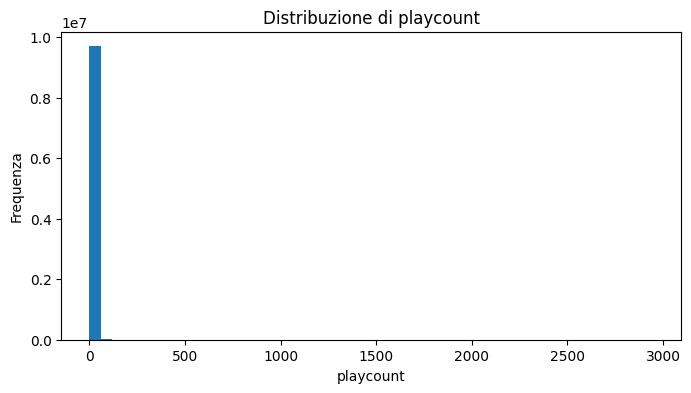

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.hist(df_hist["playcount"], bins=50)
plt.title("Distribuzione di playcount")
plt.xlabel("playcount")
plt.ylabel("Frequenza")
plt.show()

### Osservazioni

- La distribuzione risulta fortemente sbilanciata verso valori bassi
- La maggior parte dei record ha `playcount` pari a 1 o 2
- I valori più elevati sono poco frequenti e difficilmente visibili nella scala lineare

Questo comportamento è tipico di dataset reali di interazioni utente-contenuto

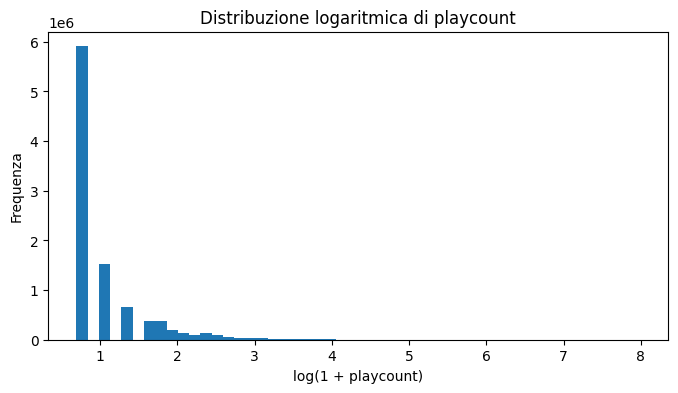

In [10]:


plt.figure(figsize=(8,4))
plt.hist(np.log1p(df_hist["playcount"]), bins=50)
plt.title("Distribuzione logaritmica di playcount")
plt.xlabel("log(1 + playcount)")
plt.ylabel("Frequenza")
plt.show()

### Osservazioni

- La trasformazione logaritmica rende la distribuzione più leggibile
- Si evidenzia una distribuzione continua con coda lunga (long tail)
- I valori elevati risultano meno compressi rispetto alla scala lineare

La presenza di una long tail indica che:
- pochi utenti ascoltano alcune tracce molto frequentemente
- la maggior parte delle interazioni è caratterizzata da pochi ascolti

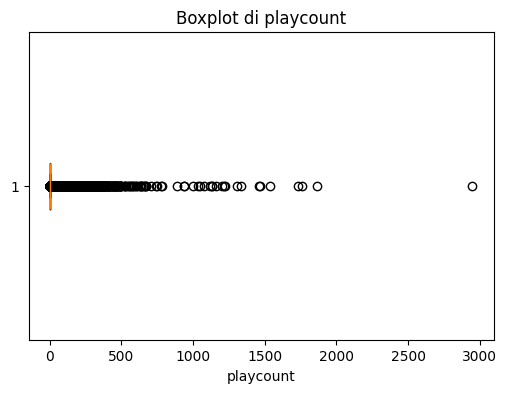

In [11]:
plt.figure(figsize=(6,4))
plt.boxplot(df_hist["playcount"], vert=False)
plt.title("Boxplot di playcount")
plt.xlabel("playcount")
plt.show()

### Osservazioni

- Il boxplot evidenzia la presenza di numerosi outlier
- La distribuzione è fortemente asimmetrica (skewed)
- La mediana è molto vicina al valore minimo

Gli outlier non rappresentano errori, ma comportamenti reali di utenti molto attivi

### Conclusioni

L’analisi della distribuzione di `playcount` conferma che:

- la variabile è fortemente sbilanciata verso valori bassi
- la maggior parte delle interazioni presenta un numero ridotto di ascolti
- è presente una lunga coda (long tail) con pochi valori molto elevati
- la distribuzione è altamente asimmetrica

Questo comportamento è tipico dei sistemi di raccomandazione e delle piattaforme di streaming musicale

Non si ritiene necessario rimuovere gli outlier, in quanto rappresentano informazioni rilevanti sul comportamento degli utenti

## 6. Preprocessing e creazione del dataset pulito

In questa sezione vengono applicate le operazioni di preprocessing sul dataset `listening_history`, sulla base delle analisi precedenti.

L’obiettivo è ottenere un dataset pulito, coerente e pronto per:
- le fasi di integrazione con `music_info`
- la modellazione del database
- eventuali analisi o sistemi di raccomandazione

### Scelte di preprocessing

Sulla base dell’analisi effettuata:

- non sono presenti valori nulli → nessuna imputazione necessaria
- non sono presenti duplicati → nessuna rimozione necessaria
- i tipi di dato risultano già coerenti → nessuna conversione richiesta
- non sono presenti valori invalidi per `playcount`

Non vengono effettuate operazioni di pulizia strutturale

I valori elevati di `playcount` non vengono rimossi, in quanto rappresentano comportamenti reali e informativi

Il dataset viene mantenuto nella sua forma originale, preservando tutta l’informazione disponibile

In [12]:
df_hist.to_csv("listening_history_cleaned.csv", index=False)

print("Dataset salvato come listening_history_cleaned.csv")

Dataset salvato come listening_history_cleaned.csv


### Conclusioni preprocessing

Le analisi effettuate non hanno evidenziato la necessità di interventi di pulizia o trasformazione dei dati.

Il dataset `listening_history` viene quindi mantenuto invariato, in quanto già coerente, completo e privo di anomalie rilevanti.

Il dataframe `df_hist_clean` rappresenta quindi una copia del dataset originale, pronta per le fasi successive del progetto.